# 05. Forecasting Monday's pump price change
Can last week's change in the ENSE reference price predict the change in pump prices on Monday?
The model is estimated with data up to 2024 and tested on 2025 and 2026, data it has never seen.

In [4]:
# Import the libraries
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# Load weekly pump prices and reference prices (already aligned in notebook 03)
df = pd.read_csv("../data/processed/ense_retail_margins.csv", parse_dates=["date"])
print(len(df), "weeks")

395 weeks


In [5]:
# Train on 2019 to 2024, test on 2025 and 2026, for each fuel
forecast_results = []
forecasts = {}

for fuel_name in ["gasoline", "diesel"]:
    # Weekly changes in the pump price and in the reference price
    data = df[["date"]].copy()
    data["d_pump"] = df[f"{fuel_name}_with_tax"].diff()
    data["d_ref"] = df[f"{fuel_name}_ref"].diff()
    data["d_ref_lag1"] = data["d_ref"].shift(1)
    data["d_pump_lag1"] = data["d_pump"].shift(1)
    data = data.dropna()

    # Split into training data and test data
    train = data[data["date"] < "2025-01-01"]
    test = data[data["date"] >= "2025-01-01"]

    # Estimate the model on the training data and predict the test weeks
    model = smf.ols("d_pump ~ d_ref + d_ref_lag1 + d_pump_lag1", data=train).fit()
    predicted = model.predict(test)

    # Average error of the model and of a simple benchmark that always predicts "no change" (cents per litre)
    error_model = (test["d_pump"] - predicted).abs().mean() * 100
    error_no_change = test["d_pump"].abs().mean() * 100
    
    # Tougher benchmark: the pump price changes exactly as much as last week's reference price
    error_full_pass = (test["d_pump"] - test["d_ref"]).abs().mean() * 100

    # Share of weeks where the model gets the direction right (up or down)
    right_direction = ((predicted > 0) == (test["d_pump"] > 0)).mean() * 100

    forecast_results.append({
        "fuel": fuel_name,
        "test_weeks": len(test),
        "avg_error_model_cents": round(error_model, 2),
        "avg_error_no_change_cents": round(error_no_change, 2),
        "avg_error_full_pass_cents": round(error_full_pass, 2),
        "right_direction_pct": round(right_direction, 1),
    })

    # Keep the actual and predicted changes for the chart (in cents)
    forecasts[fuel_name] = pd.DataFrame({
        "date": test["date"],
        "actual": test["d_pump"] * 100,
        "predicted": predicted * 100,
    })

# Show and save the results
forecast_results = pd.DataFrame(forecast_results)
forecast_results.to_csv("../data/processed/monday_forecast_results.csv", index=False)
forecast_results

,fuel,test_weeks,avg_error_model_cents,avg_error_no_change_cents,avg_error_full_pass_cents,right_direction_pct
0,gasoline,91,0.88,1.96,1.25,85.7
1,diesel,91,1.06,3.02,1.19,90.1


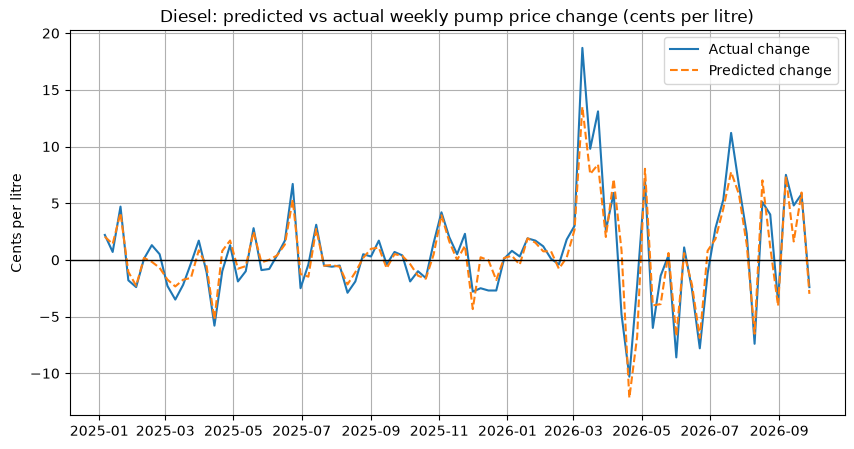

In [6]:
# Chart: actual vs predicted weekly change in the diesel pump price, 2025 and 2026
diesel = forecasts["diesel"]

plt.figure(figsize=(10, 5))
plt.plot(diesel["date"], diesel["actual"], label="Actual change")
plt.plot(diesel["date"], diesel["predicted"], label="Predicted change", linestyle="--")
plt.axhline(0, color="black", linewidth=1)
plt.title("Diesel: predicted vs actual weekly pump price change (cents per litre)")
plt.ylabel("Cents per litre")
plt.legend()
plt.grid(True)

# Save and show the chart
plt.savefig("../figures/monday_forecast_diesel.png")
plt.show()